In [1]:
import os
import sys
from pathlib import Path

# Automatically locate and add the 'src' folder to sys.path
project_root = Path(os.path.abspath(''))
src_path = project_root / "src"
if src_path not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import pandas as pd
import seaborn as sns

import pingouin as pg
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSCanonical
import scipy.stats as stats

from imaging import io

import warnings

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

DATA

In [2]:
db_base_path = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/')

db_4df_loc_tavg_flow = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedTimeAvgFlow_20260216.xlsx')
db_asl_cerebral_perfusion = pd.read_excel(db_base_path / 'PESABrain_ASLPerfusion_ThrMeanCBF_20260216.xlsx')
db_asl_vascular_perfusion = pd.read_excel(db_base_path / 'PESABrain_ASLPerfusion_VascularAtlas_MeanCBF_20260216.xlsx')

In [3]:
ids2keep = db_4df_loc_tavg_flow['patient_id'].dropna().unique()
db_asl_cerebral_perfusion = db_asl_cerebral_perfusion[db_asl_cerebral_perfusion['patient_id'].isin(ids2keep)]
db_asl_vascular_perfusion = db_asl_vascular_perfusion[db_asl_vascular_perfusion['patient_id'].isin(ids2keep)]


In [6]:
db_4df_loc_tavg_flow

,patient_id,mri_id,Left ICA,Right ICA,Basilar,Left MCA,Right MCA,Left PCA,Right PCA,Left ACA,Right ACA,Straight Sinus,Right Transverse,TCBF,Sagital Sinus,Left Transverse,Left Communicating,Right Communicating
0,PESA1006009,BMRI923674,267.035802,281.351906,184.510389,184.078000,164.954801,85.506044,87.287925,123.890140,169.345030,91.780072,19.454464,732.898097,324.326244,520.735027,NaN,NaN
1,PESA10061584,BMRI287356,94.844843,207.560577,182.850943,98.020385,125.765787,28.154514,65.765648,57.051822,59.883987,61.624851,NaN,485.256363,312.151543,82.878716,NaN,78.691079
2,PESA10067929,BMRI965424,323.586469,355.117301,228.640571,270.285622,239.059132,122.964848,114.071772,114.857424,111.551782,102.287930,580.894268,907.344340,422.249027,NaN,119.439828,NaN
3,PESA10086976,BMRI859483,303.364359,0.814246,251.966084,233.156754,239.970671,73.641519,137.637481,87.405910,39.218030,NaN,19.022995,556.144689,180.244190,NaN,NaN,NaN
4,PESA10112400,BMRI465140,325.856177,330.478438,151.450536,204.398455,193.725946,58.706137,66.667051,87.470201,178.279675,83.714123,565.937433,807.785152,357.676310,96.298434,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,PESA9897316,BMRI994162,283.497145,262.646432,178.221377,157.694022,174.874614,81.645816,80.873901,80.672484,154.428945,58.207388,144.922742,724.364954,403.755209,345.180321,NaN,NaN
353,PESA9928801,BMRI487416,314.992869,370.991649,87.832792,145.102919,145.299666,62.834793,96.432440,94.685434,108.661552,NaN,NaN,773.817309,NaN,30.023411,NaN,82.117245
354,PESA9935104,BMRI881199,352.592480,199.660541,245.827435,171.888570,187.729023,95.659605,87.211407,171.542602,121.473962,307.457462,332.273682,798.080455,44.223617,57.329407,NaN,NaN
355,PESA9947716,BMRI447102,350.185589,358.434131,309.712580,227.214842,251.342628,86.541550,122.017814,88.710539,99.947704,129.490267,520.660198,1018.332299,401.265249,159.015987,NaN,NaN


In [7]:
db_asl_cerebral_perfusion

,patient_id,mri_id,ctx-whole-brain,ctx-left-hemisphere,ctx-right-hemisphere,ctx-Left-Frontal-Lobe,ctx-Right-Frontal-Lobe,ctx-Left-Parietal-Lobe,ctx-Right-Parietal-Lobe,ctx-Left-Occipital-Lobe,...,ctx-lh-supramarginal,ctx-rh-supramarginal,ctx-lh-frontalpole,ctx-rh-frontalpole,ctx-lh-temporalpole,ctx-rh-temporalpole,ctx-lh-transversetemporal,ctx-rh-transversetemporal,ctx-lh-insula,ctx-rh-insula
4,PESA1006009,BMRI923674,64.850706,63.393821,66.288385,61.740562,67.408806,65.866269,66.219254,68.494657,...,70.501571,66.337672,41.135369,45.495737,45.353493,63.197503,86.056837,101.617334,73.281913,66.009448
5,PESA10061584,BMRI287356,43.683496,44.220321,43.141605,47.603980,46.732966,40.246246,39.902791,34.840381,...,50.799021,47.145552,31.168418,33.848858,33.180599,38.073534,90.733841,89.418925,50.660214,47.770352
6,PESA10067929,BMRI965424,71.819444,69.764533,73.896158,73.099998,78.830215,72.674399,73.207479,61.950238,...,72.003542,76.447145,42.920038,70.644649,57.445183,53.397544,108.038543,114.353554,64.231830,70.063355
8,PESA10086976,BMRI859483,65.740547,63.598031,67.886590,66.062868,71.197841,63.642918,67.478100,67.300755,...,69.424932,72.195391,47.448542,57.956494,36.550477,48.152944,110.679341,120.952501,70.094283,70.181632
11,PESA10112400,BMRI465140,57.550002,56.656838,58.416831,61.264373,66.376576,58.871804,59.446548,44.994553,...,64.160298,64.732177,51.250193,58.278440,33.273097,40.720725,87.879807,78.047400,52.807864,53.297792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,PESA9897316,BMRI994162,61.322542,61.321816,61.323249,64.739682,65.505272,62.114230,60.455759,51.744403,...,74.621176,73.783925,46.238957,57.087102,44.433810,45.621905,109.107237,92.846363,66.061780,65.461524
1377,PESA9928801,BMRI487416,64.188529,62.430920,65.940574,64.194265,67.159171,65.913547,69.022435,61.966851,...,66.454711,69.110715,60.415644,48.864500,39.256088,50.280340,83.611113,110.187125,52.963441,61.087635
1378,PESA9935104,BMRI881199,56.903359,57.807313,55.979328,61.096123,59.512227,60.576383,57.947922,49.279588,...,62.117535,60.765123,45.450613,38.303936,50.585845,42.351298,76.626570,94.461272,57.649229,53.173355
1379,PESA9947716,BMRI447102,72.428656,69.965742,74.834474,74.731206,81.009304,70.948384,74.830753,60.644756,...,73.590404,81.980738,54.296013,67.199032,64.226084,54.961856,118.281604,121.530419,78.202405,87.974662


In [8]:
db_asl_vascular_perfusion

,mri_id,Left_ACA-0,Left_ACA-8,Left_ACA-12,Left_Basilar-0,Left_Basilar-8,Left_Basilar-12,Left_MCA-0,Left_MCA-8,Left_MCA-12,...,Right_MCA-0,Right_MCA-8,Right_MCA-12,Right_PCA-0,Right_PCA-8,Right_PCA-12,Watershed-0,Watershed-8,Watershed-12,patient_id
3,BMRI103891,48.946068,43.587774,41.160999,35.171541,31.433283,29.929284,51.165630,45.593088,42.314514,...,48.637071,42.965971,39.850815,33.429471,30.154596,29.246237,39.446082,34.031072,31.965095,PESA7001316
4,BMRI104117,60.469264,52.294099,48.137339,47.720029,42.422542,39.864675,67.547891,59.580308,54.904342,...,54.248643,47.804756,44.148345,45.443906,40.658271,38.859358,52.400004,43.320047,39.447128,PESA10233601
5,BMRI104385,49.499974,41.397637,38.143148,51.750600,33.223507,31.555873,53.155346,43.869502,40.138668,...,51.620772,42.014830,38.258516,49.807396,42.201304,39.527214,35.373936,29.305245,27.319556,PESA1359556
6,BMRI104820,61.896512,55.711387,52.484186,61.638843,56.493086,54.125773,61.772102,54.928824,51.013397,...,60.126105,53.704822,49.838528,63.990240,58.087600,55.182201,52.674583,45.902232,42.816480,PESA6416089
7,BMRI105334,63.044853,56.058626,52.433125,47.472897,45.547853,44.622138,67.075732,58.761334,54.148884,...,66.368251,57.912745,53.306087,51.149472,47.255383,45.173776,55.402297,48.016116,44.341866,PESA9972964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949,BMRI994162,62.924751,55.688677,51.901720,48.193862,45.282989,43.508663,65.856892,56.265623,51.471456,...,63.579420,53.550264,48.870513,49.456065,44.541762,42.311120,49.923600,42.002036,38.684027,PESA9897316
951,BMRI994731,57.464760,51.277672,47.782345,46.068094,43.416559,42.131193,66.099945,57.143940,52.507394,...,61.086146,52.435128,48.159073,47.789929,42.413695,40.446022,47.443763,40.757882,37.834970,PESA14807104
952,BMRI994933,45.936615,41.368063,39.143776,41.325338,36.886579,34.595851,51.458620,44.545872,41.036517,...,51.792058,44.462046,40.846169,37.347653,33.618010,32.118307,40.507084,34.391536,31.932311,PESA7661824
957,BMRI999786,51.739173,45.897137,43.082698,50.918693,46.758400,44.324995,55.889382,48.197342,44.400068,...,53.731692,46.205937,42.491687,45.479607,41.514476,39.746589,44.398802,37.589021,34.713421,PESA6482116


ASL Desikan Atlas PearsonR

In [4]:
_db_4df_loc_tavg_flow = db_4df_loc_tavg_flow.drop(columns=[
    'TCBF',
    'Sagital Sinus',
    'Straight Sinus',
    'Right Transverse',
    'Left Transverse',
    'Left Communicating',
    'Right Communicating',
])
_db_asl_cerebral_perfusion = db_asl_cerebral_perfusion.drop(columns=[
    'ctx-whole-brain',
    'ctx-Left-Frontal-Lobe',
    'ctx-Right-Frontal-Lobe',
    'ctx-Left-Parietal-Lobe',
    'ctx-Right-Parietal-Lobe',
    'ctx-Left-Occipital-Lobe',
    'ctx-Right-Occipital-Lobe',
    'ctx-Left-Temporal-Lobe',
    'ctx-Right-Temporal-Lobe',
    'ctx-Left-Anterior-Cingulate',
    'ctx-Right-Anterior-Cingulate',
    'ctx-left-hemisphere',
    'ctx-right-hemisphere',
])

In [5]:
import statsmodels.formula.api as smf
from nilearn import datasets, surface, plotting
import matplotlib.pyplot as plt

def calculate_flow_perfusion_correlations(df_flow, df_fs_asl):
    """
    Creates a correlation matrix where:
    Rows = 4D Flow Vessels
    Columns = FreeSurfer Cortical Regions
    """
    merged = pd.merge(df_flow, df_fs_asl, on=['patient_id', 'mri_id'], how='inner')
    
    vessels = ['Left ICA', 'Right ICA', 'Basilar', 'Left MCA', 'Right MCA', 
               'Left PCA', 'Right PCA', 'Left ACA', 'Right ACA']
    
    regions = [col for col in df_fs_asl.columns if col.startswith('ctx-')]
    
    corr_matrix = pd.DataFrame(index=vessels, columns=regions)
    
    for v in vessels:
        for r in regions:
            valid = merged[[v, r]].dropna()
            if len(valid) > 2: 
                corr_matrix.loc[v, r] = np.corrcoef(valid[v], valid[r])[0, 1]
            else:
                corr_matrix.loc[v, r] = 0
                
    return corr_matrix.astype(float)


def calculate_flow_vascular_perfusion_correlations(df_flow, df_fs_asl, smoothing=8):
    """
    Creates a correlation matrix where:
    Rows = 4D Flow Vessels
    Columns = FreeSurfer Cortical Regions
    """
    merged = pd.merge(df_flow, df_fs_asl, on=['patient_id', 'mri_id'], how='inner')
    
    vessels = ['Left ICA', 'Right ICA', 'Basilar', 'Left MCA', 'Right MCA', 
               'Left PCA', 'Right PCA', 'Left ACA', 'Right ACA']
    
    regions = [col for col in df_fs_asl.columns if col.endswith(f"-{smoothing}")]
    
    corr_matrix = pd.DataFrame(index=vessels, columns=regions)
    
    for v in vessels:
        for r in regions:
            valid = merged[[v, r]].dropna()
            if len(valid) > 2: 
                corr_matrix.loc[v, r] = np.corrcoef(valid[v], valid[r])[0, 1]
            else:
                corr_matrix.loc[v, r] = 0
                
    return corr_matrix.astype(float)


def plot_atlas_correlation(
    corr_matrix, vessel_name, hemisphere='left', 
    shared_minmax=True, thr=None,
    bg_on_data=True, 
):
    # 1. Setup Atlas and Mesh
    fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
    destrieux = datasets.fetch_atlas_surf_destrieux()
    
    if hemisphere == 'left':
        surf_mesh = fsaverage.pial_left
        bg_map = fsaverage.curv_left
        atlas_map = destrieux['map_left']
        prefix = 'ctx-lh-'
    else:
        surf_mesh = fsaverage.pial_right
        bg_map = fsaverage.curv_right
        atlas_map = destrieux['map_right']
        prefix = 'ctx-rh-'

    # 2. Manual DK-to-Destrieux Mapping Dictionary
    # This matches your ASL labels to the keywords in the Destrieux labels provided.
    mapping_logic = {
        'superiorfrontal': ['G_front_sup', 'S_front_sup'],
        'precentral': ['G_precentral', 'S_precentral'],
        'postcentral': ['G_postcentral', 'S_postcentral'],
        'precuneus': ['G_precuneus', 'S_subparietal'],
        'cuneus': ['G_cuneus', 'S_calcarine'],
        'paracentral': ['paracentral'],
        'insula': ['insular', 'Ins_lg'],
        'superiorparietal': ['G_parietal_sup', 'S_intrapariet'],
        'supramarginal': ['Supramar'],
        'inferiorparietal': ['Angular'],
        'superiortemporal': ['G_temp_sup-Lateral', 'S_temporal_sup'],
        'middletemporal': ['G_temporal_middle'],
        'inferiortemporal': ['G_temporal_inf', 'S_temporal_inf'],
        'fusiform': ['fusifor'],
        'lingual': ['Lingual'],
        'entorhinal': ['Parahip', 'entorhinal'],
        'parahippocampal': ['Parahip'],
        'lateraloccipital': ['occipital_middle', 'occipital_sup', 'oc-temp_lat'],
        'caudalmiddlefrontal': ['G_front_middle'],
        'rostralmiddlefrontal': ['S_front_middle'],
        'parsopercularis': ['Opercular'],
        'parstriangularis': ['Triangul'],
        'parsorbitalis': ['Orbital'],
        'lateralorbitofrontal': ['S_orbital_lateral'],
        'medialorbitofrontal': ['G_rectus', 'S_orbital_med'],
        'caudalanteriorcingulate': ['cingul-Mid-Ant'],
        'rostralanteriorcingulate': ['cingul-Ant'],
        'posteriorcingulate': ['cingul-Mid-Post'],
        'isthmuscingulate': ['cingul-Post-ventral'],
        'bankssts': ['S_temporal_sup'], # Approximate
        'transversetemporal': ['transv_frontopol', 'G_temp_sup-G_T_transv'],
        'temporalpole': ['Pole_temporal'],
        'frontalpole': ['frontomargin'],
        'pericalcarine': ['S_calcarine']
    }

    # 3. Process Data
    vessel_series = corr_matrix.loc[vessel_name]
    vertex_values = np.zeros(atlas_map.shape)
    destrieux_labels = destrieux['labels']
    
    mapped_regions = []

    # Loop through every vertex-label in the Destrieux atlas
    for i, d_label in enumerate(destrieux_labels):
        if i == 0: continue # Skip 'Unknown'
        
        # Check our mapping logic
        for dk_key, keywords in mapping_logic.items():
            full_data_label = f"{prefix}{dk_key}"
            
            if full_data_label in vessel_series.index:
                # If any keyword matches the Destrieux label name
                if any(kw.lower() in d_label.lower() for kw in keywords):
                    vertex_values[atlas_map == i] = vessel_series[full_data_label]
                    mapped_regions.append(dk_key)

    print(f"Mapped {len(set(mapped_regions))}/34 regions for {vessel_name} ({hemisphere})")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': '3d'})

    if shared_minmax:
        vmin, vmax = corr_matrix.values.min(), corr_matrix.values.max()
    else:
        vmin, vmax = vertex_values.min(), vertex_values.max()

    thr = thr if thr > vmin and thr < vmax else None

    # Lateral View
    plotting.plot_surf_stat_map(
        surf_mesh, vertex_values, hemi=hemisphere,
        colorbar=False, bg_map=bg_map, threshold=thr,
        cmap='RdBu_r', view='lateral', axes=axes[0],
        symmetric_cbar=True, #vmin=vmin, vmax=vmax, 
        bg_on_data=bg_on_data, 
    )
    axes[0].set_title(f"{vessel_name} - Lateral")

    # Medial View
    plotting.plot_surf_stat_map(
        surf_mesh, vertex_values, hemi=hemisphere,
        colorbar=True, bg_map=bg_map, threshold=thr,
        cmap='RdBu_r', view='medial', axes=axes[1],
        symmetric_cbar=True, #vmin=vmin, vmax=vmax, 
        bg_on_data=bg_on_data, 
    )
    axes[1].set_title(f"{vessel_name} - Medial")

    fig.suptitle(f"Data-Driven Correlation Atlas: {vessel_name} ({hemisphere} hemisphere)", fontsize=16)
    return fig


<Axes: >

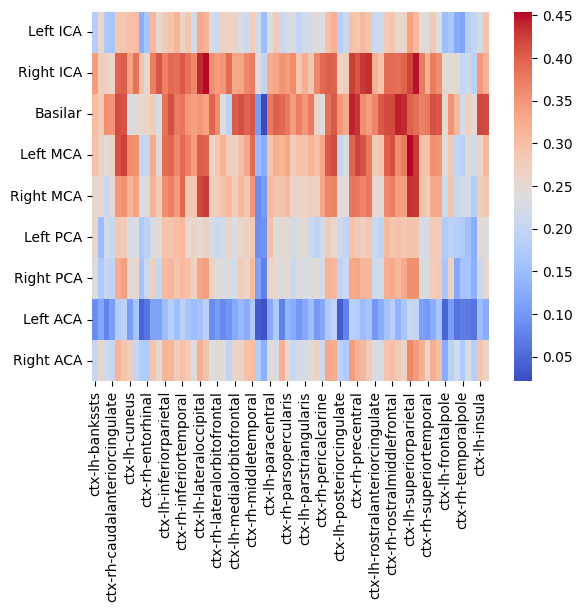

In [41]:
corrs = calculate_flow_perfusion_correlations(_db_4df_loc_tavg_flow, _db_asl_cerebral_perfusion)
sns.heatmap(corrs, annot=False, cmap='coolwarm') #, vmin=-1, vmax=1)

[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Right MCA (right)


[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Left MCA (left)


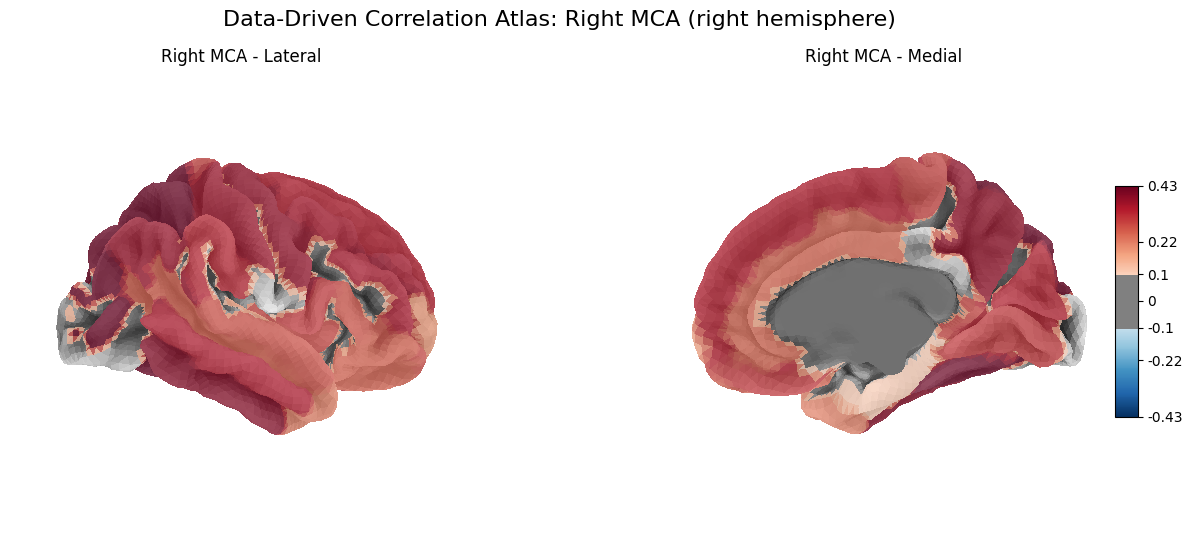

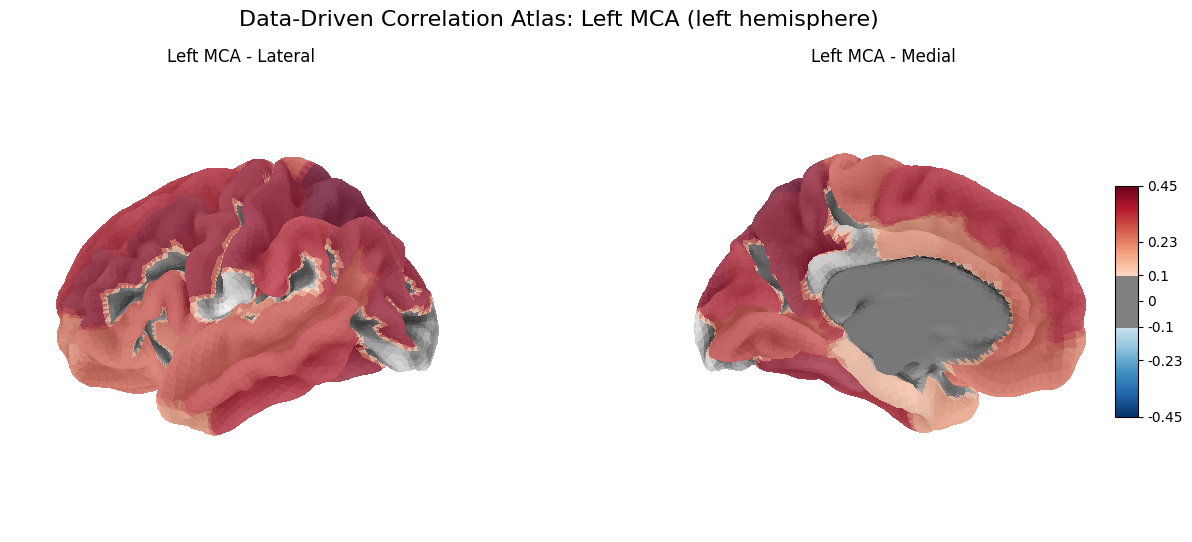

In [51]:
fig_r = plot_atlas_correlation(corrs, 'Right MCA', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_atlas_correlation(corrs, 'Left MCA', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

ASL Vascular Atlas PearsonR

In [6]:
_db_4df_loc_tavg_flow = db_4df_loc_tavg_flow.drop(columns=[
    'TCBF',
    'Sagital Sinus',
    'Straight Sinus',
    'Right Transverse',
    'Left Transverse',
    'Left Communicating',
    'Right Communicating',
]) 

_db_asl_vascular_perfusion = db_asl_vascular_perfusion


<Axes: >

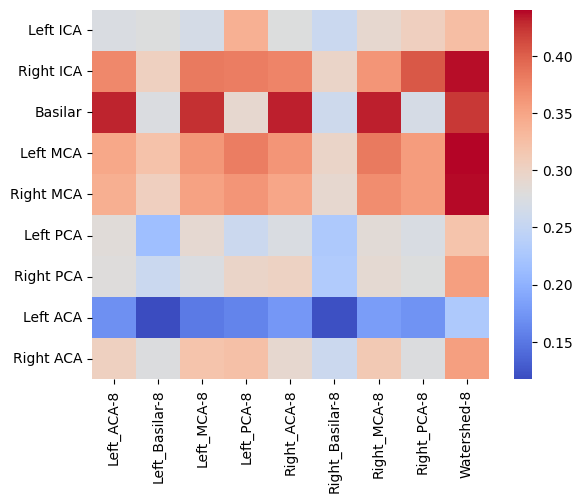

In [7]:

corrs = calculate_flow_vascular_perfusion_correlations(_db_4df_loc_tavg_flow, _db_asl_vascular_perfusion)
sns.heatmap(corrs, annot=False, cmap='coolwarm')

ASL Desikan Atlas Partial Correlation

In [8]:
import pingouin as pg

_db_4df_loc_tavg_flow = db_4df_loc_tavg_flow.drop(columns=[
    # 'TCBF',
    'Sagital Sinus',
    'Straight Sinus',
    'Right Transverse',
    'Left Transverse',
    'Left Communicating',
    'Right Communicating',
]) 
_db_asl_cerebral_perfusion = db_asl_cerebral_perfusion.drop(columns=[
    'ctx-whole-brain',
    'ctx-Left-Frontal-Lobe',
    'ctx-Right-Frontal-Lobe',
    'ctx-Left-Parietal-Lobe',
    'ctx-Right-Parietal-Lobe',
    'ctx-Left-Occipital-Lobe',
    'ctx-Right-Occipital-Lobe',
    'ctx-Left-Temporal-Lobe',
    'ctx-Right-Temporal-Lobe',
    'ctx-Left-Anterior-Cingulate',
    'ctx-Right-Anterior-Cingulate',
    'ctx-left-hemisphere',
    'ctx-right-hemisphere',
])
_db_asl_vascular_perfusion = db_asl_vascular_perfusion

df_merged = pd.merge(_db_4df_loc_tavg_flow, _db_asl_cerebral_perfusion, on=['patient_id', 'mri_id'])
df_merged = pd.merge(df_merged, _db_asl_vascular_perfusion, on=['patient_id', 'mri_id'])

vessel_cols = ['Left ICA', 'Right ICA', 'Basilar', 'Left MCA', 'Right MCA', 
               'Left PCA', 'Right PCA', 'Left ACA', 'Right ACA']

desikan_cols = [c for c in _db_asl_cerebral_perfusion.columns if c.startswith('ctx-')]

vascular_asl_cols = [c for c in _db_asl_vascular_perfusion.columns if '-8' in c]



In [56]:
df_merged

,patient_id,mri_id,Left ICA,Right ICA,Basilar,Left MCA,Right MCA,Left PCA,Right PCA,Left ACA,...,Right_Basilar-12,Right_MCA-0,Right_MCA-8,Right_MCA-12,Right_PCA-0,Right_PCA-8,Right_PCA-12,Watershed-0,Watershed-8,Watershed-12
0,PESA1006009,BMRI923674,267.035802,281.351906,184.510389,184.078000,164.954801,85.506044,87.287925,123.890140,...,59.265807,65.198261,56.890992,52.548045,67.190744,59.861298,56.557791,59.358839,50.179122,46.080686
1,PESA10061584,BMRI287356,94.844843,207.560577,182.850943,98.020385,125.765787,28.154514,65.765648,57.051822,...,29.903507,46.390193,38.077766,34.945077,34.404296,29.311260,27.789391,32.567112,27.110815,25.230741
2,PESA10067929,BMRI965424,323.586469,355.117301,228.640571,270.285622,239.059132,122.964848,114.071772,114.857424,...,61.994569,70.462878,61.698699,56.916442,63.974914,59.397221,56.697057,63.765126,55.872769,51.524710
3,PESA10086976,BMRI859483,303.364359,0.814246,251.966084,233.156754,239.970671,73.641519,137.637481,87.405910,...,50.366541,68.105543,60.446592,55.802385,58.919810,55.156248,52.796240,58.022184,51.348714,47.755473
4,PESA10112400,BMRI465140,325.856177,330.478438,151.450536,204.398455,193.725946,58.706137,66.667051,87.470201,...,33.083139,58.768344,51.371223,47.128029,46.109057,42.014865,40.201927,53.332548,46.215967,42.125014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,PESA9897316,BMRI994162,283.497145,262.646432,178.221377,157.694022,174.874614,81.645816,80.873901,80.672484,...,43.200720,63.579420,53.550264,48.870513,49.456065,44.541762,42.311120,49.923600,42.002036,38.684027
352,PESA9928801,BMRI487416,314.992869,370.991649,87.832792,145.102919,145.299666,62.834793,96.432440,94.685434,...,54.281276,66.576420,58.131150,53.433672,67.379842,60.351909,56.554558,56.158168,49.882072,46.368077
353,PESA9935104,BMRI881199,352.592480,199.660541,245.827435,171.888570,187.729023,95.659605,87.211407,171.542602,...,38.235175,61.654321,54.130418,49.733312,44.295691,40.179098,38.552354,52.956606,46.629408,42.928430
354,PESA9947716,BMRI447102,350.185589,358.434131,309.712580,227.214842,251.342628,86.541550,122.017814,88.710539,...,48.330358,82.429635,72.198803,66.727948,54.557471,49.731519,47.736959,64.102314,55.293241,50.994882


In [57]:
print(vessel_cols)
print(desikan_cols)

['Left ICA', 'Right ICA', 'Basilar', 'Left MCA', 'Right MCA', 'Left PCA', 'Right PCA', 'Left ACA', 'Right ACA']
['ctx-lh-bankssts', 'ctx-rh-bankssts', 'ctx-lh-caudalanteriorcingulate', 'ctx-rh-caudalanteriorcingulate', 'ctx-lh-caudalmiddlefrontal', 'ctx-rh-caudalmiddlefrontal', 'ctx-lh-cuneus', 'ctx-rh-cuneus', 'ctx-lh-entorhinal', 'ctx-rh-entorhinal', 'ctx-lh-fusiform', 'ctx-rh-fusiform', 'ctx-lh-inferiorparietal', 'ctx-rh-inferiorparietal', 'ctx-lh-inferiortemporal', 'ctx-rh-inferiortemporal', 'ctx-lh-isthmuscingulate', 'ctx-rh-isthmuscingulate', 'ctx-lh-lateraloccipital', 'ctx-rh-lateraloccipital', 'ctx-lh-lateralorbitofrontal', 'ctx-rh-lateralorbitofrontal', 'ctx-lh-lingual', 'ctx-rh-lingual', 'ctx-lh-medialorbitofrontal', 'ctx-rh-medialorbitofrontal', 'ctx-lh-middletemporal', 'ctx-rh-middletemporal', 'ctx-lh-parahippocampal', 'ctx-rh-parahippocampal', 'ctx-lh-paracentral', 'ctx-rh-paracentral', 'ctx-lh-parsopercularis', 'ctx-rh-parsopercularis', 'ctx-lh-parsorbitalis', 'ctx-rh-par

<Axes: xlabel='Region', ylabel='Vessel'>

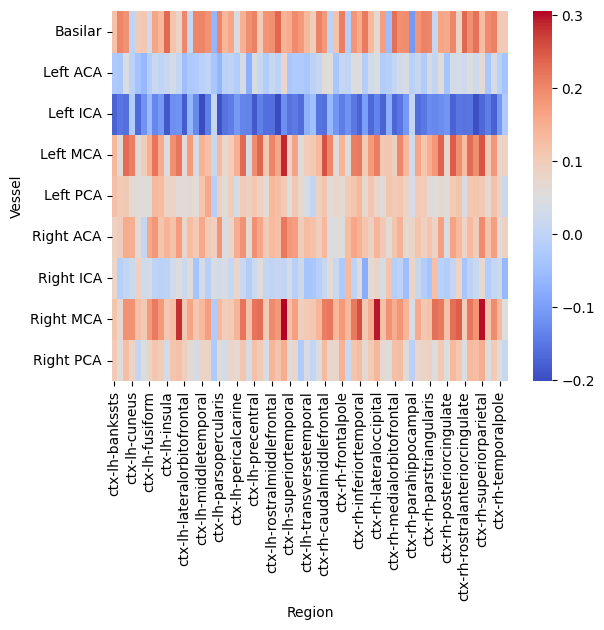

In [9]:
def analyze_partial_correlations(df, vessels, regions, covar=['TCBF']):
    results = []
    for v in vessels:
        for r in regions:
            valid = df[[v, r] + covar].dropna()
            if len(valid) > 15:
                res = pg.partial_corr(data=valid, x=v, y=r, covar=covar)
                results.append({'Vessel': v, 'Region': r, 'r': res['r'].values[0], 'p': res['p_val'].values[0]})
    
    corr_matrix = pd.DataFrame(results).pivot(index='Vessel', columns='Region', values='r')
    p_matrix = pd.DataFrame(results).pivot(index='Vessel', columns='Region', values='p')
    return corr_matrix, p_matrix


corrs, pvals = analyze_partial_correlations(df_merged, vessel_cols, desikan_cols)
sns.heatmap(corrs, annot=False, cmap='coolwarm')

[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Right MCA (right)


[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Left MCA (left)


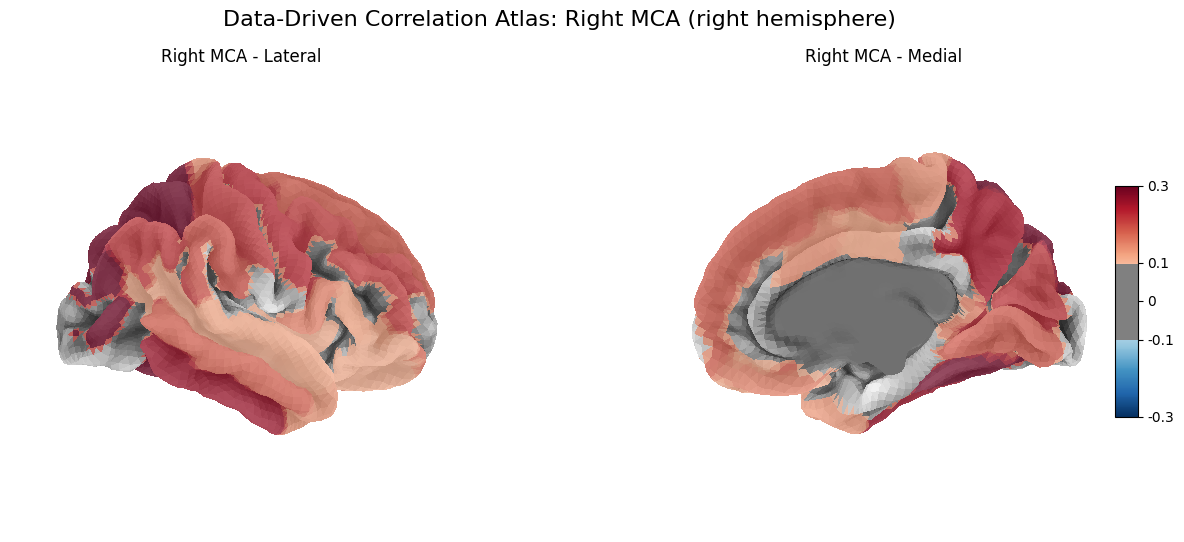

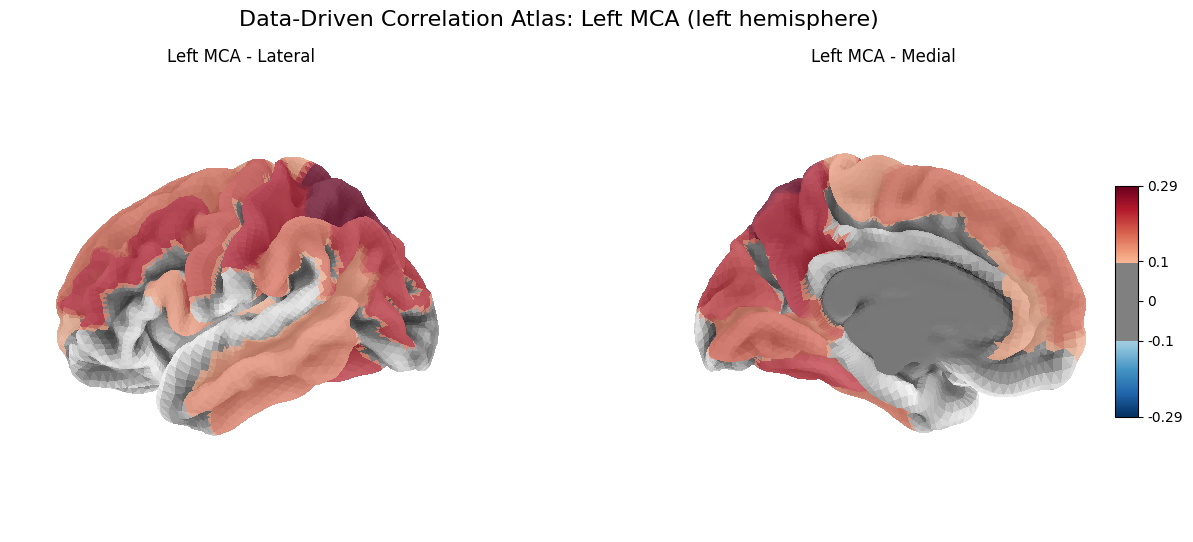

In [62]:
fig_r = plot_atlas_correlation(corrs, 'Right MCA', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_atlas_correlation(corrs, 'Left MCA', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

ELASTICNET

In [15]:
def run_region_wise_elasticnet(df, vessel_cols, region_cols):
    """
    Predicts each ASL region's perfusion using all 4D flow vessels.
    """
    # Standardize predictors (Vessels)
    X = df[vessel_cols].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Make sure we align indices
    aligned_df = df.loc[X.index]
    
    model_coefficients = pd.DataFrame(index=vessel_cols)
    model_scores = {}
    
    # Fit an Elastic Net for every region
    for region in region_cols:
        y = aligned_df[region]
        
        # Drop rows where y is NaN for this specific region
        valid_idx = y.dropna().index
        X_valid = X_scaled[aligned_df.index.isin(valid_idx)]
        y_valid = y.dropna()
        
        # ElasticNetCV automatically finds the best L1/L2 ratio and alpha
        enet = ElasticNetCV(cv=5, l1_ratio=[.1, .5, .7, .9, .95, 1], random_state=42)
        enet.fit(X_valid, y_valid)
        
        # Store the learned weights (betas) for this region
        model_coefficients[region] = enet.coef_
        model_scores[region] = enet.score(X_valid, y_valid) # R-squared
        
    return model_coefficients, pd.Series(model_scores)

In [124]:
betas, r2s = run_region_wise_elasticnet(df_merged, vessel_cols, desikan_cols)

<Axes: >

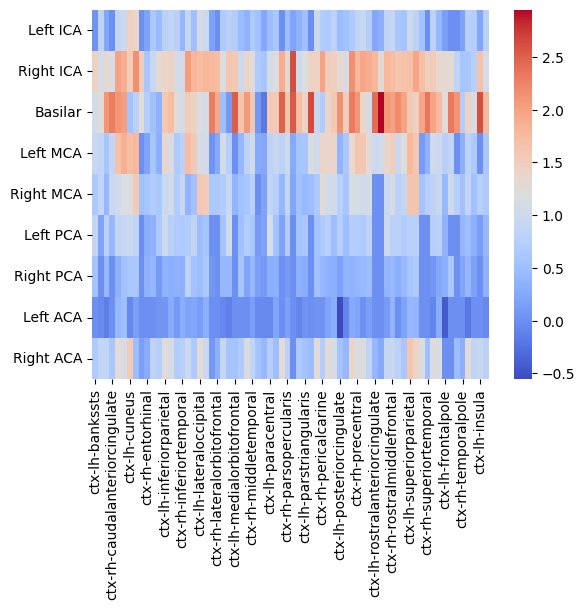

In [65]:
sns.heatmap(betas, annot=False, cmap='coolwarm')

[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Right MCA (right)


[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Left MCA (left)


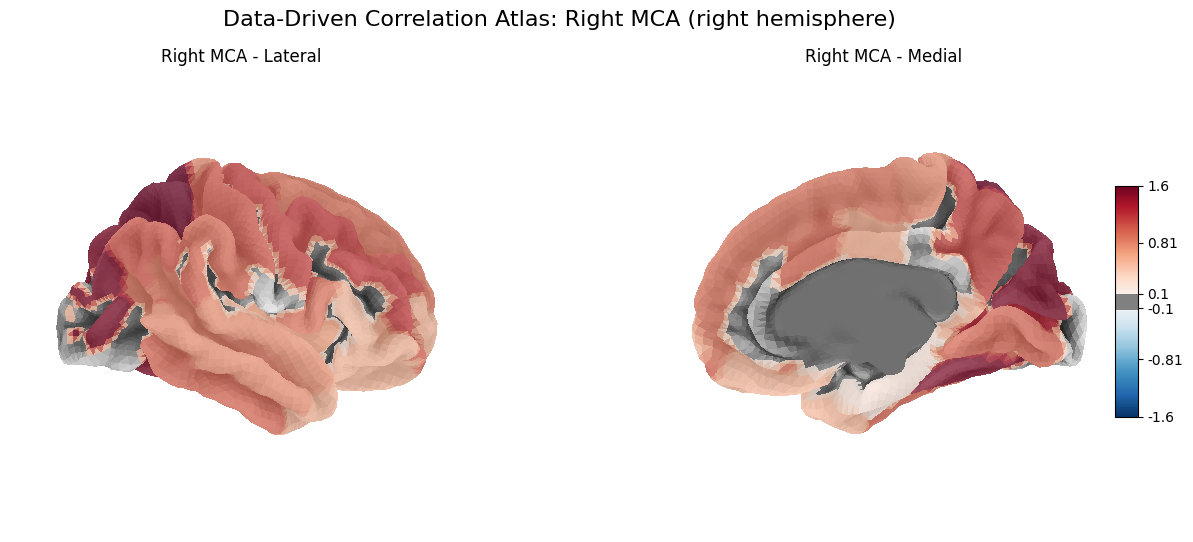

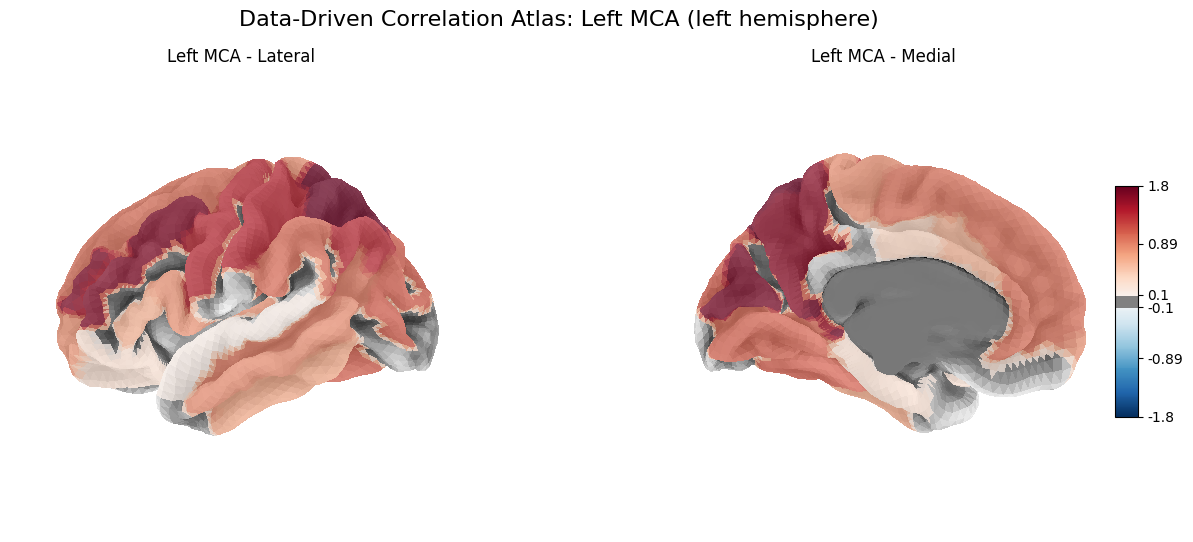

In [67]:
fig_r = plot_atlas_correlation(betas, 'Right MCA', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_atlas_correlation(betas, 'Left MCA', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Basilar (right)


[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Basilar (left)


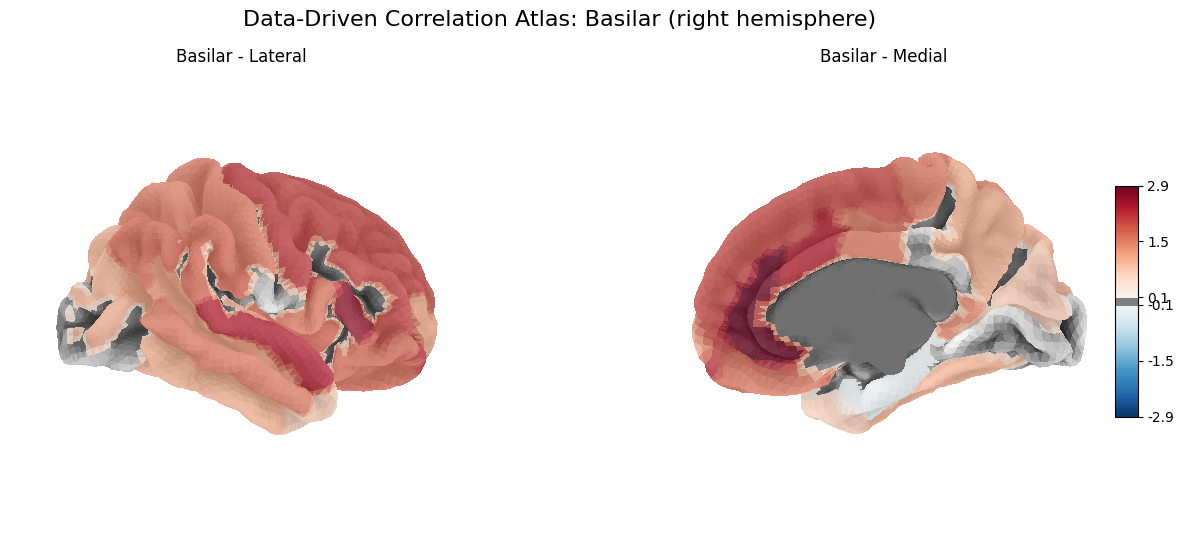

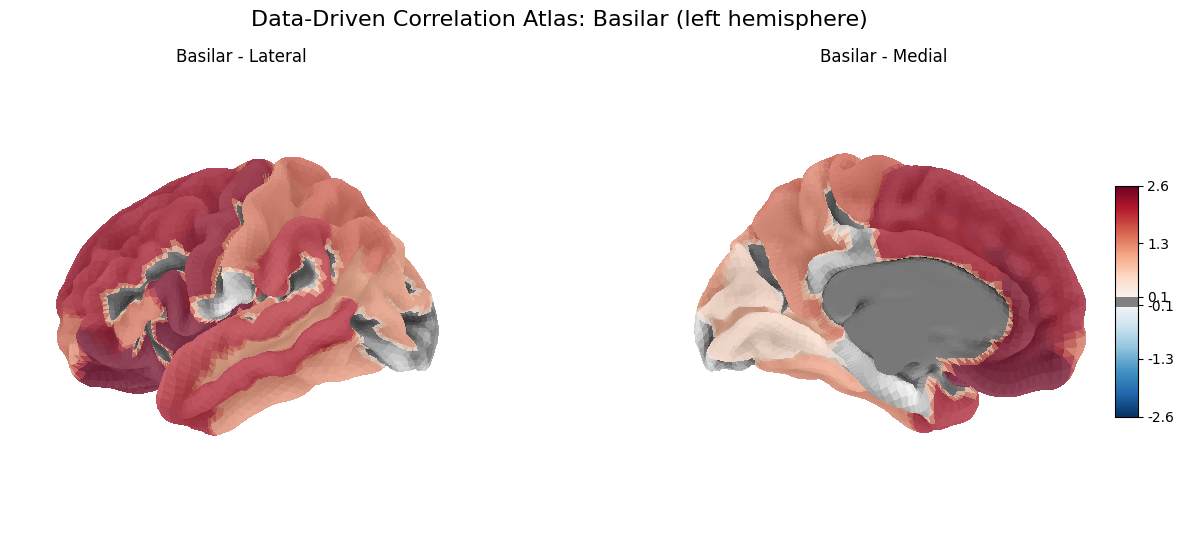

In [ ]:
fig_r = plot_atlas_correlation(betas, 'Basilar', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_atlas_correlation(betas, 'Basilar', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Right ICA (right)


[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Left ICA (left)


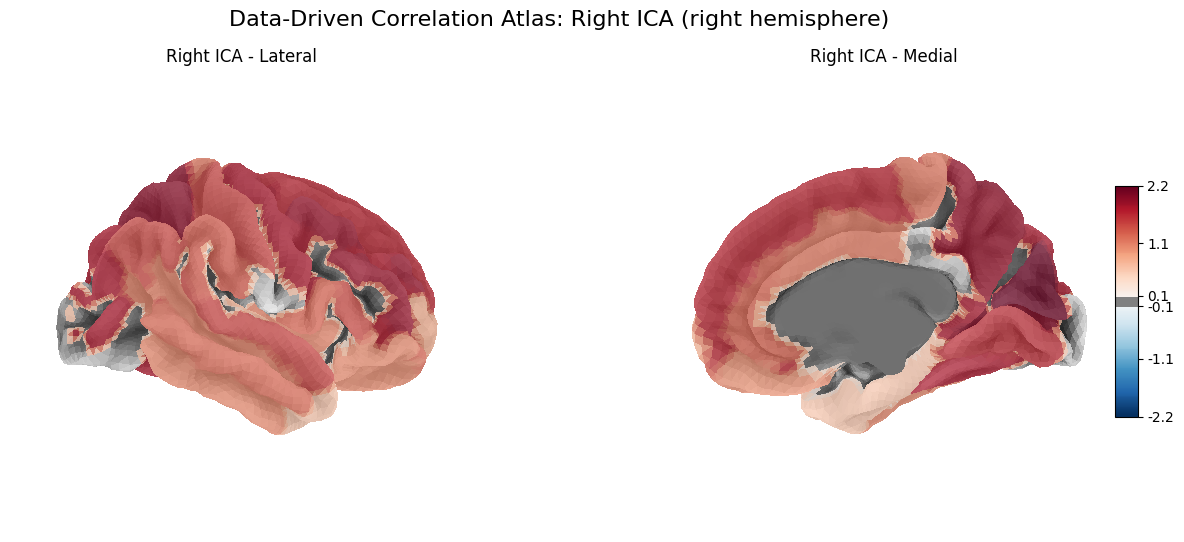

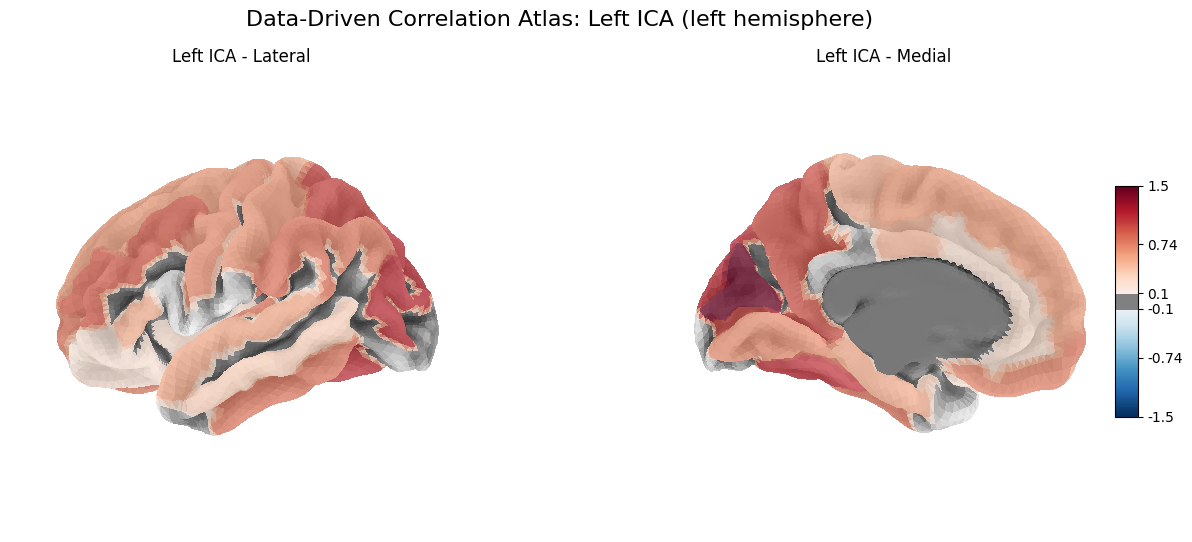

In [151]:
fig_r = plot_atlas_correlation(betas, 'Right ICA', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_atlas_correlation(betas, 'Left ICA', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

<Axes: >

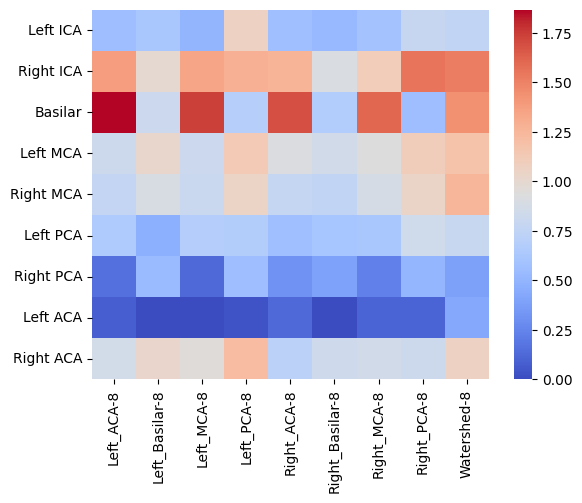

In [16]:
betas_v, r2s_v = run_region_wise_elasticnet(df_merged, vessel_cols, vascular_asl_cols)
sns.heatmap(betas_v, annot=False, cmap='coolwarm')

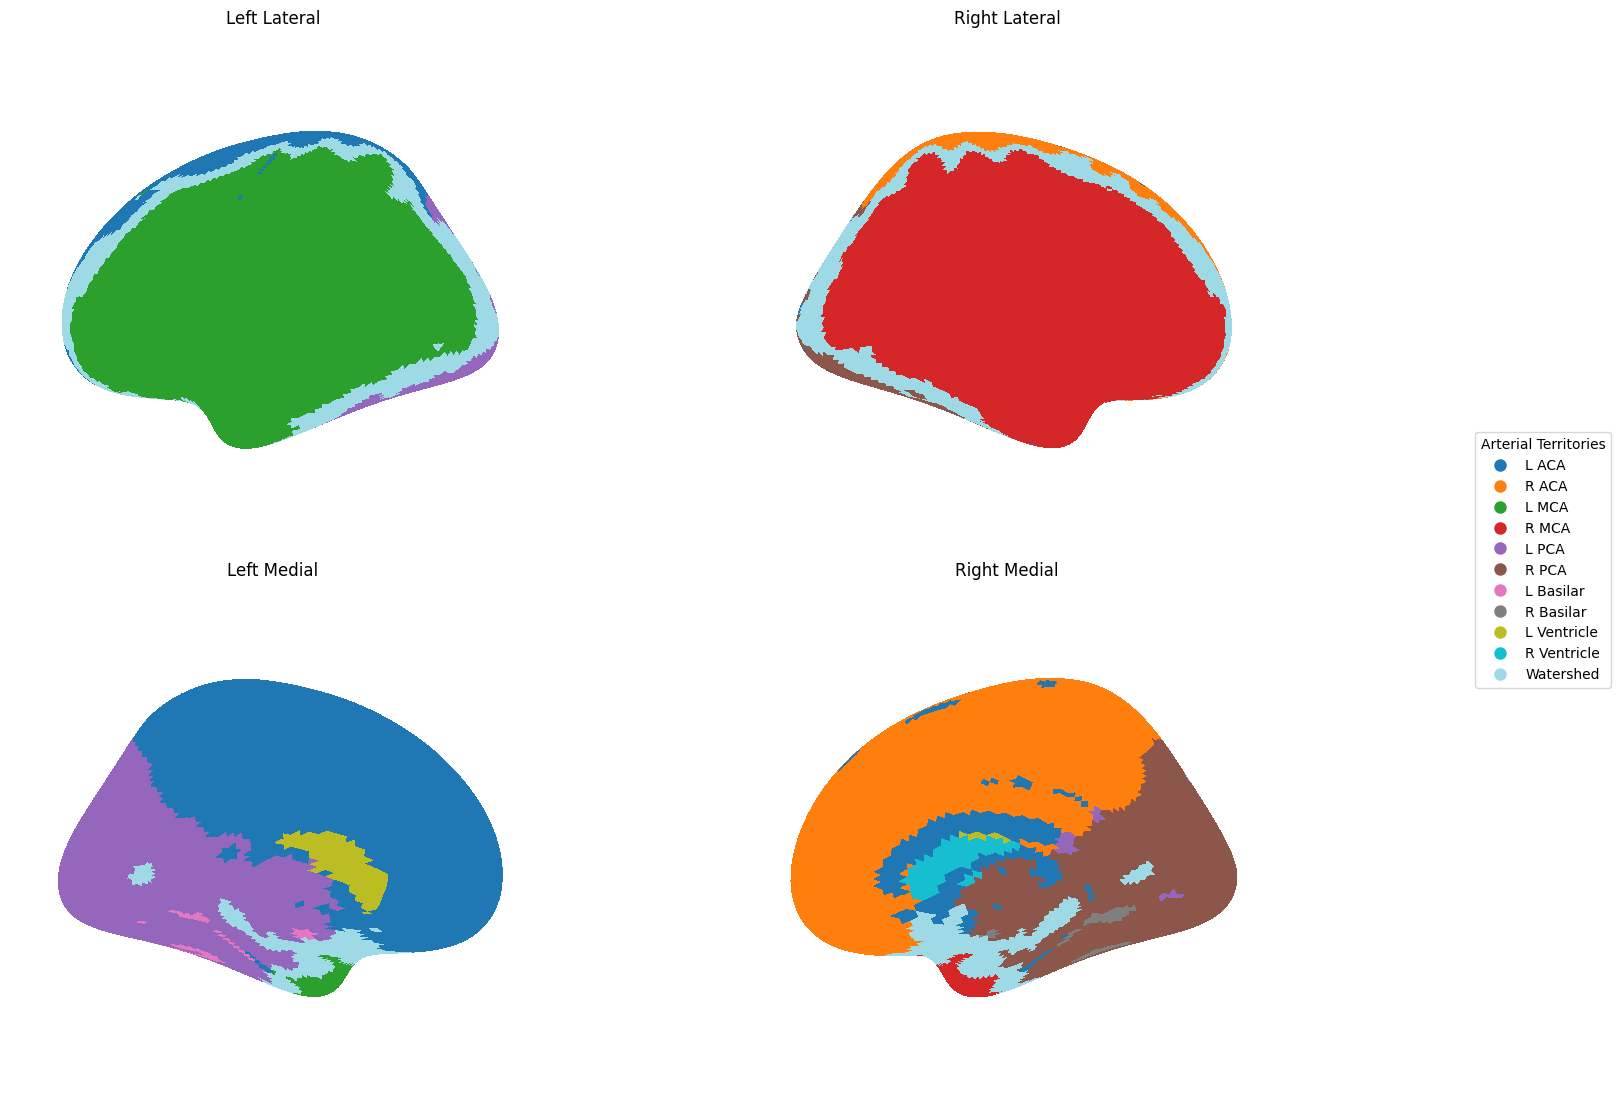

In [10]:
from nilearn import datasets, surface, plotting, image
import nibabel as nib

# Load atlas and target surface
v_atlas = nib.load('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/ATLAS/arterial_atlas_watershed_tpm_correct_space.nii.gz')
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')


def _mask_hemisphere(img, side='left'):
    data = img.get_fdata().copy()
    affine = img.affine
    # Create a grid of all voxel indices
    coords = np.array(np.meshgrid(
        np.arange(data.shape[0]), 
        np.arange(data.shape[1]), 
        np.arange(data.shape[2]), indexing='ij'
    )).reshape(3, -1)
    
    # Transform indices to MNI space
    mni_coords = image.coord_transform(coords[0], coords[1], coords[2], affine)
    x_mni = mni_coords[0].reshape(data.shape)
    
    if side == 'left':
        data[x_mni > 0] = 0  # Zero out the Right MNI side
    else:
        data[x_mni < 0] = 0  # Zero out the Left MNI side

    # data[data == 9] = 1
    # data[data == 10] = 2
        
    return image.new_img_like(img, data)

vol_lh = _mask_hemisphere(v_atlas, side='left')
vol_rh = _mask_hemisphere(v_atlas, side='right')

# Project volume to surface
texture_lh = surface.vol_to_surf(vol_lh, fsaverage.pial_left, interpolation='nearest_most_frequent', radius=1.5)#, inner_mesh=fsaverage.white_left)
texture_rh = surface.vol_to_surf(vol_rh, fsaverage.pial_right, interpolation='nearest_most_frequent', radius=1.5)#, inner_mesh=fsaverage.white_left)

fig = plt.figure(figsize=(20, 14))
cmap = plt.get_cmap('tab20', 11)

views = [
    {'mesh': fsaverage.infl_left,  'tex': texture_lh, 'hemi': 'left',  'view': 'lateral', 'title': 'Left Lateral'},
    {'mesh': fsaverage.infl_right, 'tex': texture_rh, 'hemi': 'right', 'view': 'lateral', 'title': 'Right Lateral'},
    {'mesh': fsaverage.infl_left,  'tex': texture_lh, 'hemi': 'left',  'view': 'medial',  'title': 'Left Medial'},
    {'mesh': fsaverage.infl_right, 'tex': texture_rh, 'hemi': 'right', 'view': 'medial',  'title': 'Right Medial'}
]

for i, v in enumerate(views):
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_roi(
        v['mesh'], roi_map=v['tex'],
        hemi=v['hemi'], view=v['view'],
        bg_map=fsaverage.sulc_left if v['hemi']=='left' else fsaverage.sulc_right,
        axes=ax, cmap=cmap, vmin=1, vmax=11,
        title=v['title'],
        colorbar=False
    )

from matplotlib.lines import Line2D
label_names = {
    1: 'L ACA', 2: 'R ACA', 3: 'L MCA', 4: 'R MCA',
    5: 'L PCA', 6: 'R PCA', 7: 'L Basilar', 8: 'R Basilar',
    9: 'L Ventricle', 10: 'R Ventricle',
    11: 'Watershed'
}

legend_elements = [
    Line2D(
        [0], [0], marker='o', color='w', label=label_names[i+1],
        markerfacecolor=cmap(i), 
        markersize=10
    ) for i in range(11)
]
fig.legend(handles=legend_elements, loc='center right', title="Arterial Territories")

plt.subplots_adjust(wspace=-0.1, hspace=0.05)
plt.show()

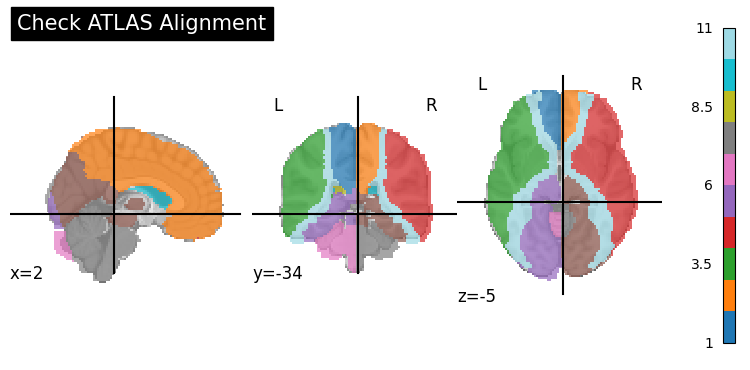

In [11]:
plotting.plot_roi(v_atlas, display_mode='ortho', title="Check ATLAS Alignment", cmap=plt.get_cmap('tab20', 11))

In [12]:
def plot_vascular_correlation(
    corr_matrix, target_vessel, hemisphere='left', 
    shared_minmax=True, thr=None, bg_on_data=True
):
    """
    Plots correlations projected onto the Vascular Watershed Atlas.
    """
    # 1. Setup Surface and Vascular Texture
    fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

    v_atlas = nib.load('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/ATLAS/arterial_atlas_watershed_tpm_correct_space.nii.gz')

    vol_lh = _mask_hemisphere(v_atlas, side='left')
    vol_rh = _mask_hemisphere(v_atlas, side='right')
    texture_lh = surface.vol_to_surf(vol_lh, fsaverage.pial_left, interpolation='nearest_most_frequent', radius=1.5)
    texture_rh = surface.vol_to_surf(vol_rh, fsaverage.pial_right, interpolation='nearest_most_frequent', radius=1.5)

    current_atlas_texture = texture_lh if hemisphere == 'left' else texture_rh
    surf_mesh = fsaverage.infl_left if hemisphere == 'left' else fsaverage.infl_right
    bg_map = fsaverage.sulc_left if hemisphere == 'left' else fsaverage.sulc_right

    # 2. Define the Mapping: ID to Matrix Column Name
    id_to_col = {
        1: 'L ACA', 2: 'R ACA', 3: 'L MCA', 4: 'R MCA',
        5: 'L PCA', 6: 'R PCA', 7: 'L Basilar', 8: 'R Basilar',
        11: 'Watershed'
        # 9 and 10 (Ventricles) are skipped 
    }

    # 3. Process Data: Map matrix values to vertices
    vessel_series = corr_matrix.loc[target_vessel]
    vessel_series = vessel_series.rename(lambda x: x.split('-')[0].replace('Right_', 'R ').replace('Left_', 'L '))
    vertex_values = np.zeros(current_atlas_texture.shape)
    
    mapped_count = 0
    for atlas_id, col_name in id_to_col.items():
        if col_name in vessel_series.index:
            # Assign the correlation value to all vertices belonging to this vascular ID
            vertex_values[current_atlas_texture == atlas_id] = vessel_series[col_name]
            mapped_count += 1

    print(f"Mapped {mapped_count} vascular territories for {target_vessel} ({hemisphere})")

    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': '3d'})

    if shared_minmax:
        vmin, vmax = corr_matrix.values.min(), corr_matrix.values.max()
    else:
        vmin, vmax = vertex_values.min(), vertex_values.max()

    # Apply thresholding if provided
    actual_thr = thr if (thr is not None and thr > 0) else None

    # Common plotting parameters
    plot_params = {
        'surf_mesh': surf_mesh, 'stat_map': vertex_values, 'hemi': hemisphere,
        'bg_map': bg_map, 'threshold': actual_thr, 'cmap': 'RdBu_r',
        'symmetric_cbar': True, 'bg_on_data': bg_on_data, # 'vmin': vmin, 'vmax': vmax
    }

    # Lateral View
    plotting.plot_surf_stat_map(axes=axes[0], view='lateral', colorbar=False, **plot_params)
    axes[0].set_title(f"{target_vessel} - Lateral", fontsize=12)

    # Medial View
    plotting.plot_surf_stat_map(axes=axes[1], view='medial', colorbar=True, **plot_params)
    axes[1].set_title(f"{target_vessel} - Medial", fontsize=12)

    fig.suptitle(f"Vascular Correlation Atlas: {target_vessel}\n({hemisphere} hemisphere projection)", fontsize=16)
    
    return fig

Mapped 9 vascular territories for Basilar (right)
Mapped 9 vascular territories for Basilar (left)


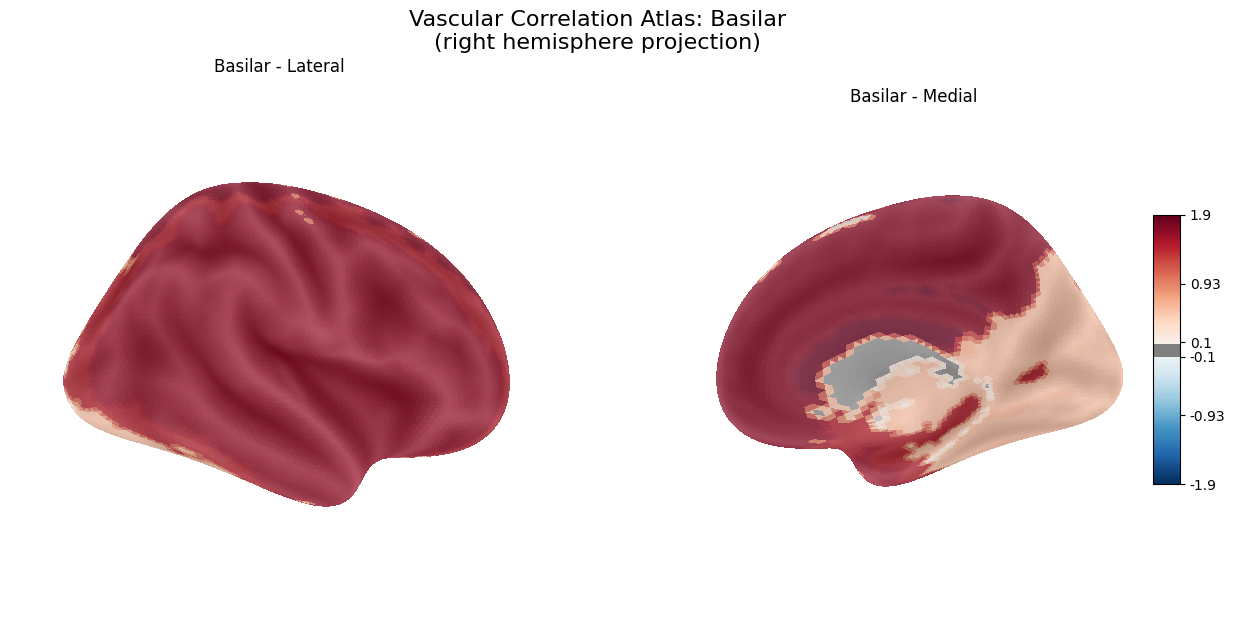

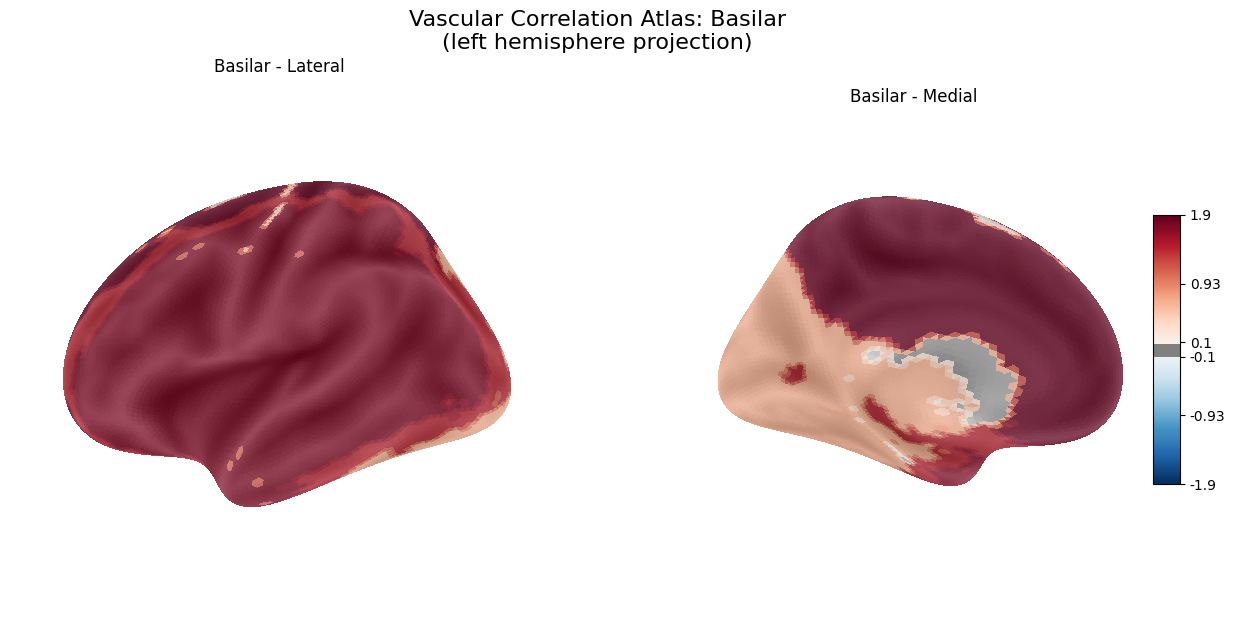

In [166]:
fig_r = plot_vascular_correlation(betas_v, 'Basilar', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_vascular_correlation(betas_v, 'Basilar', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

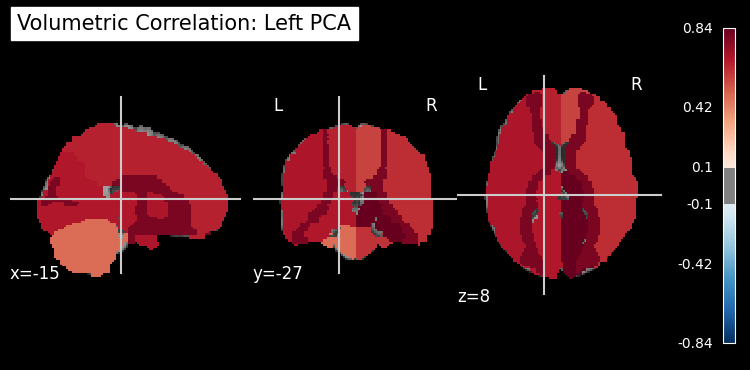

In [21]:
def plot_vascular_volumetric_correlation(
    corr_matrix, target_vessel, 
    atlas_path='/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/ATLAS/arterial_atlas_watershed_tpm_correct_space.nii.gz',
    thr=None, title=None
):
    """
    Reconstructs a 3D correlation volume from the vascular atlas and plots it.
    """
    # 1. Load the Vascular Atlas Volume
    v_atlas_img = nib.load(atlas_path)
    v_atlas_data = v_atlas_img.get_fdata()
    
    # 2. Define Mapping (Atlas ID -> Matrix Name)
    # Matching your matrix column cleaning logic
    id_to_col = {
        1: 'L ACA', 2: 'R ACA', 3: 'L MCA', 4: 'R MCA',
        5: 'L PCA', 6: 'R PCA', 7: 'L Basilar', 8: 'R Basilar',
        11: 'Watershed'
    }

    # 3. Extract and Clean target correlations
    # Expects columns like 'Left_MCA-0' -> 'L MCA'
    vessel_series = corr_matrix.loc[target_vessel].copy()
    vessel_series.index = [
        col.split('-')[0].replace('Right_', 'R ').replace('Left_', 'L ') 
        for col in vessel_series.index
    ]

    # 4. Reconstruct the 3D Stat Map
    # Initialize an empty volume with the same shape as the atlas
    stat_map_data = np.zeros(v_atlas_data.shape)
    
    for atlas_id, col_name in id_to_col.items():
        if col_name in vessel_series.index:
            correlation_value = vessel_series[col_name]
            # Fill all voxels belonging to this territory ID
            stat_map_data[v_atlas_data == atlas_id] = correlation_value

    # Create a new NIfTI object for plotting
    stat_map_img = nib.Nifti1Image(stat_map_data, v_atlas_img.affine)

    # 5. Visualization using plot_stat_map
    # We use stat_map instead of ROI to get the RdBu colorbar (Red=Pos, Blue=Neg)
    plotting.plot_stat_map(
        stat_map_img,
        display_mode='ortho', # Show Axial, Sagittal, Coronal
        cut_coords=None,      # Automatic best-slice detection
        threshold=thr,
        cmap='RdBu_r',
        symmetric_cbar=True,
        black_bg=True,
        title=title if title else f"Volumetric Correlation: {target_vessel}"
    )
    

plot_vascular_volumetric_correlation(betas_v, 'Left PCA', thr=0.1)


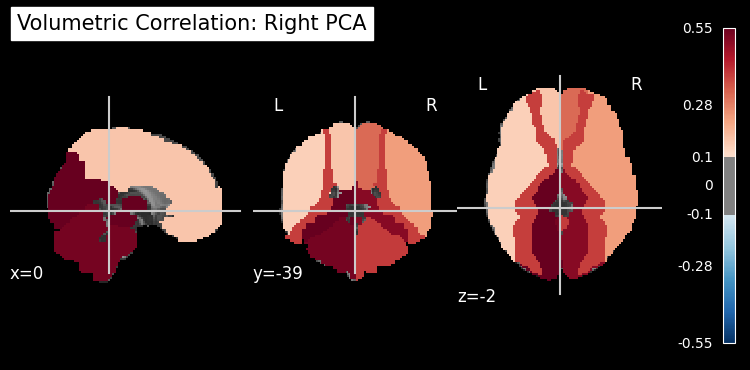

In [22]:
plot_vascular_volumetric_correlation(betas_v, 'Right PCA', thr=0.1)

Partial Least Squares (System-level)

In [69]:
def run_pls_analysis(df, vessel_cols, region_cols, n_components=3):
    """
    Extracts latent network components linking flow to perfusion.
    """
    # PLS requires no missing data in the arrays
    clean_df = df.dropna(subset=vessel_cols + region_cols)
    
    X = StandardScaler().fit_transform(clean_df[vessel_cols])
    Y = StandardScaler().fit_transform(clean_df[region_cols])
    
    pls = PLSCanonical(n_components=n_components)
    pls.fit(X, Y)
    
    # X_weights_ shape: (n_vessels, n_components)
    # Y_weights_ shape: (n_regions, n_components)
    vessel_loadings = pd.DataFrame(pls.x_weights_, index=vessel_cols, 
                                   columns=[f'Comp_{i+1}' for i in range(n_components)])
    region_loadings = pd.DataFrame(pls.y_weights_, index=region_cols, 
                                   columns=[f'Comp_{i+1}' for i in range(n_components)])
    
    return vessel_loadings, region_loadings

<Axes: >

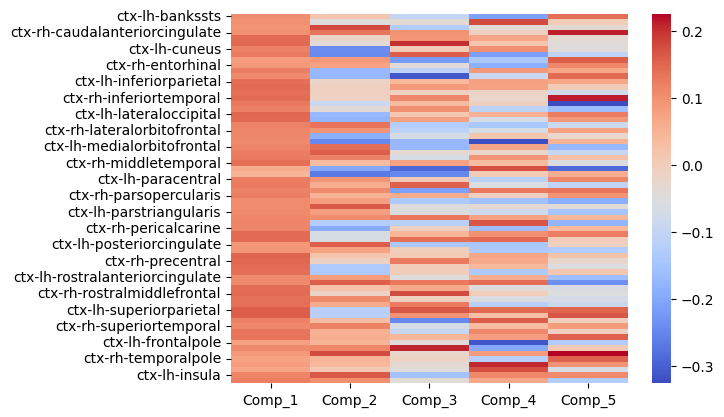

In [75]:
v_loads, r_loads = run_pls_analysis(df_merged, vessel_cols, desikan_cols, n_components=5)
# sns.heatmap(v_loads, annot=False, cmap='coolwarm')
sns.heatmap(r_loads, annot=False, cmap='coolwarm')

<Axes: >

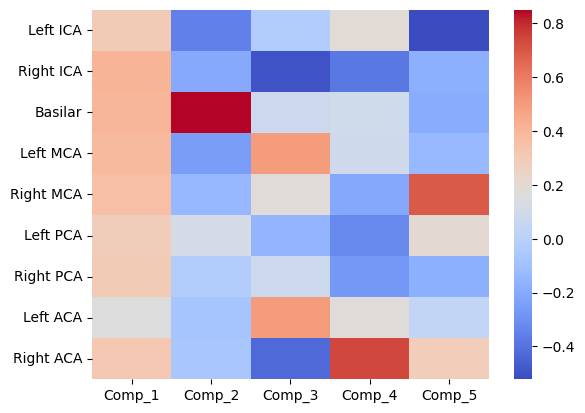

In [76]:
sns.heatmap(v_loads, annot=False, cmap='coolwarm')

[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Comp_1 (right)


[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Comp_1 (left)


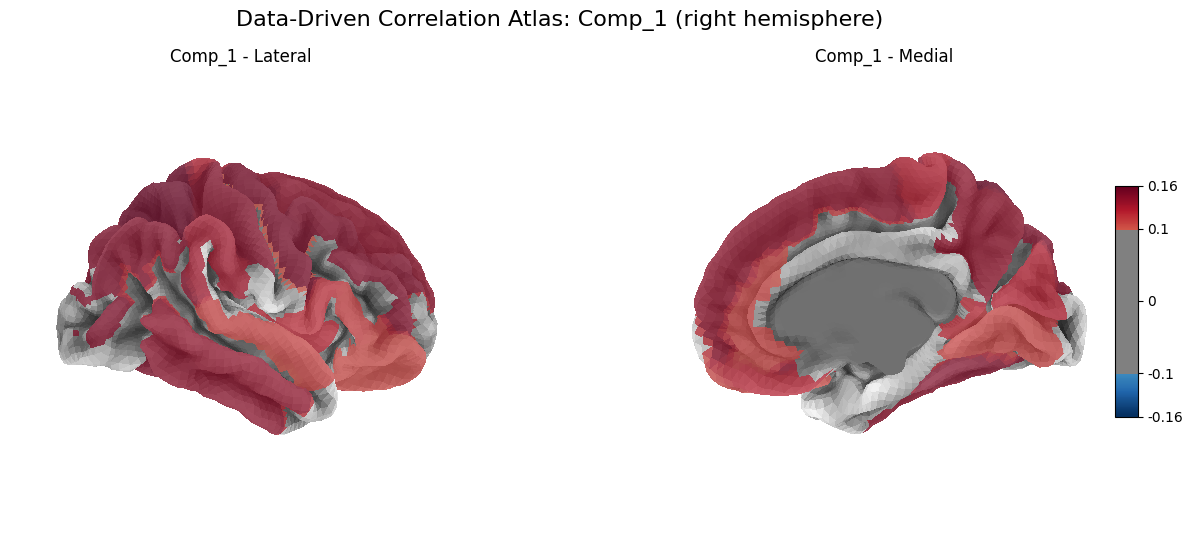

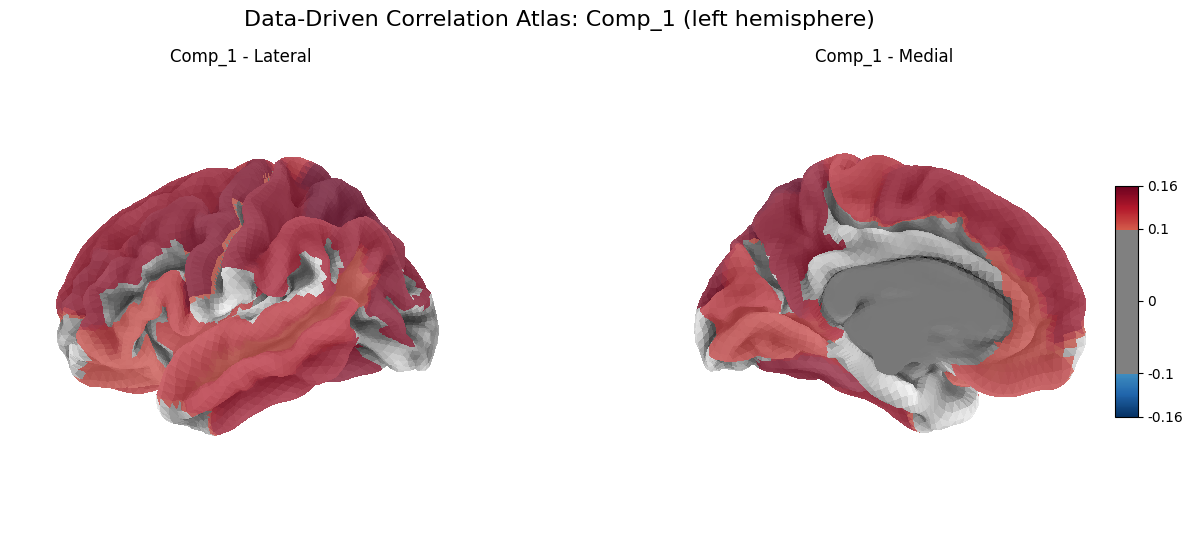

In [77]:
fig_r = plot_atlas_correlation(r_loads.T, 'Comp_1', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_atlas_correlation(r_loads.T, 'Comp_1', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Comp_2 (right)


[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Comp_2 (left)


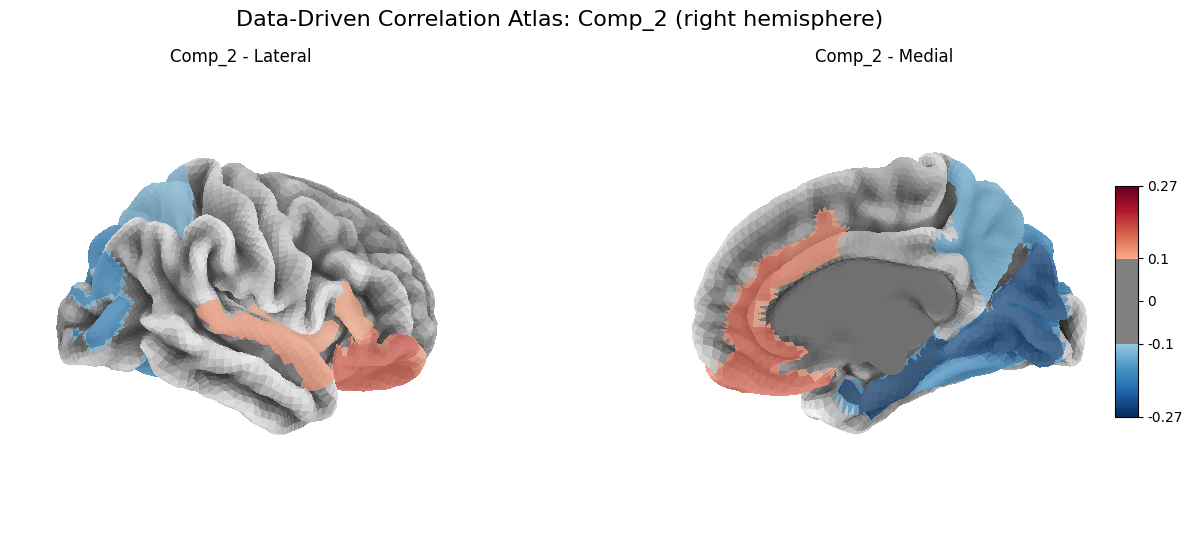

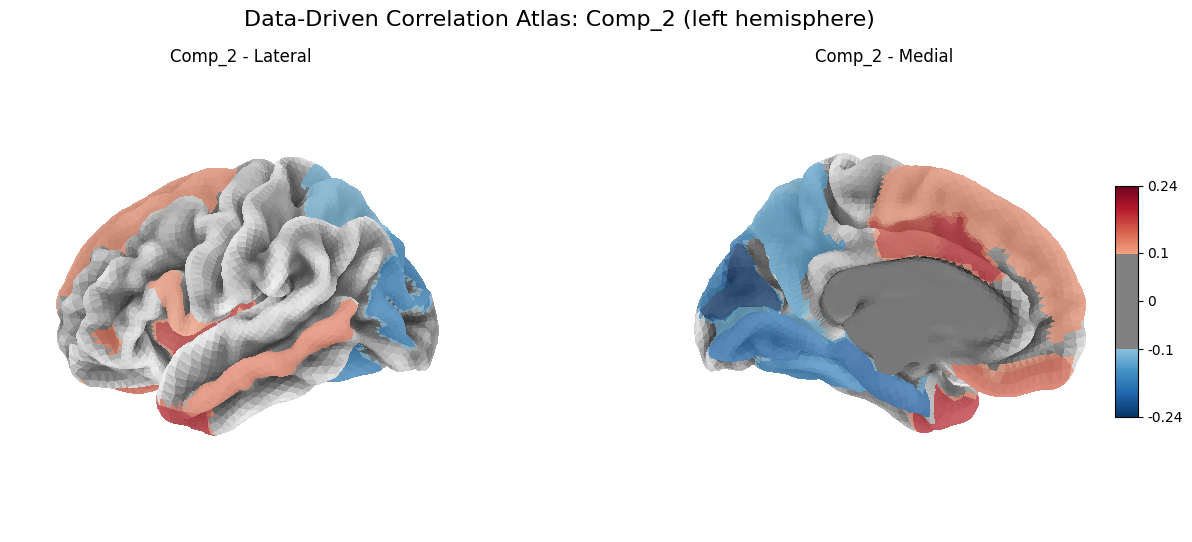

In [78]:
fig_r = plot_atlas_correlation(r_loads.T, 'Comp_2', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_atlas_correlation(r_loads.T, 'Comp_2', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Comp_3 (right)


[fetch_atlas_surf_destrieux] Dataset found in /home/imarcoss/nilearn_data/destrieux_surface

Mapped 34/34 regions for Comp_3 (left)


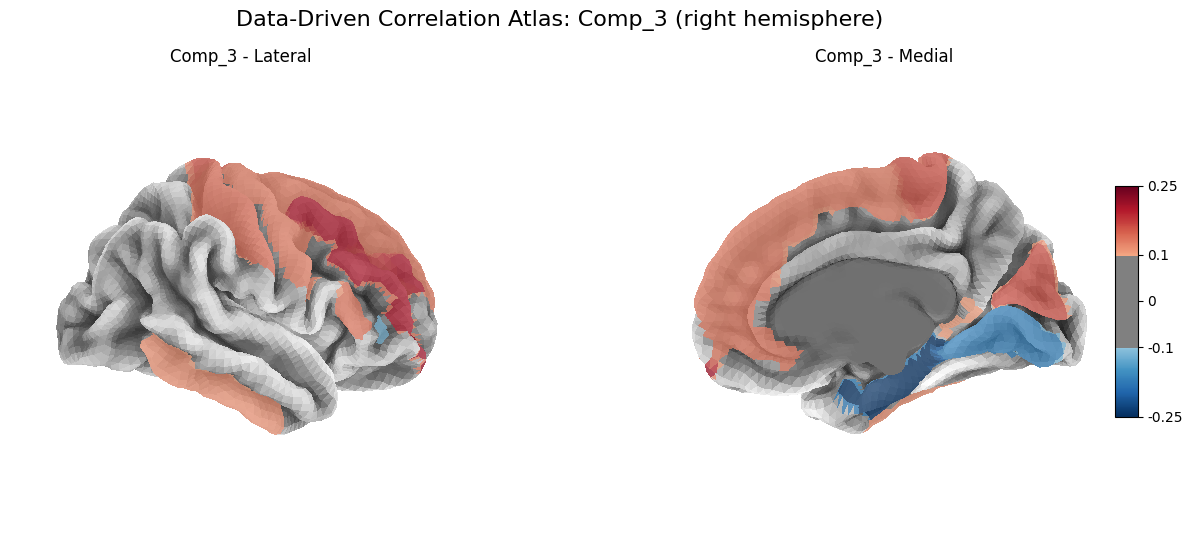

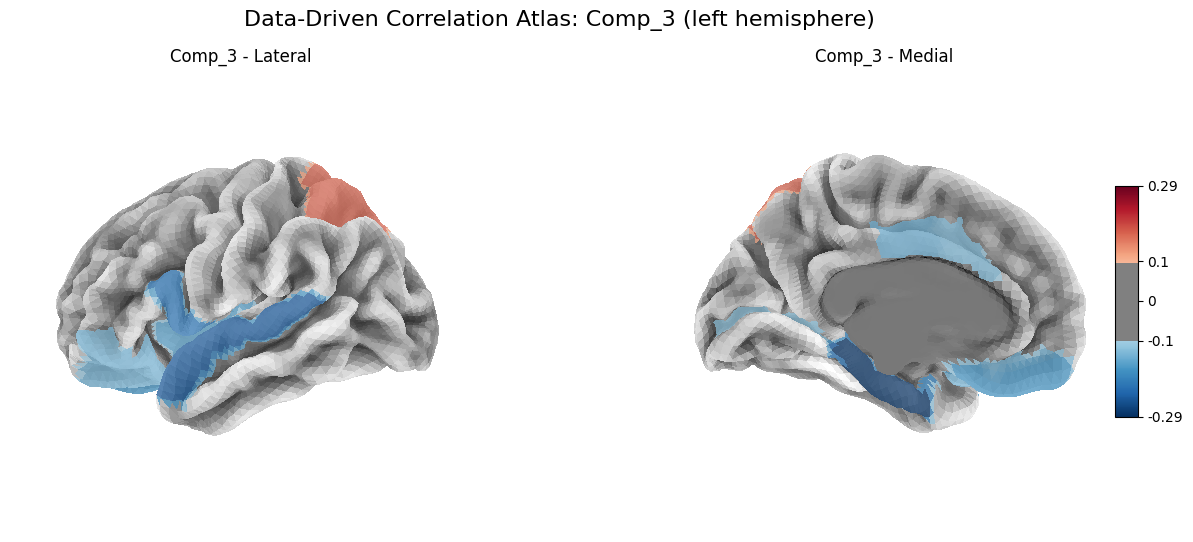

In [79]:
fig_r = plot_atlas_correlation(r_loads.T, 'Comp_3', hemisphere='right', bg_on_data=True, thr=0.1)
fig_l = plot_atlas_correlation(r_loads.T, 'Comp_3', hemisphere='left', bg_on_data=True, thr=0.1)
plt.show()

In [80]:
def compute_vascular_mismatch(df, paired_dict):
    """
    paired_dict maps the 4DFlow vessel to its corresponding ASL vascular territory.
    e.g., {'Left MCA': 'ASL_Left_MCA_Territory'}
    """
    mismatch_df = pd.DataFrame(index=df.index)
    
    for vessel, territory in paired_dict.items():
        # Clean data for the pair
        temp_df = df[[vessel, territory]].dropna()
        
        # 1. Z-score standardisation (to put mL/min and ASL units on the same scale)
        z_flow = stats.zscore(temp_df[vessel])
        z_perfusion = stats.zscore(temp_df[territory])
        
        # 2. Calculate the Mismatch Index (Perfusion relative to Flow)
        # Positive value = "Hyperemic" or maximally dilated (Perfusion > Flow)
        # Negative value = "Oligemic" or increased resistance (Flow > Perfusion)
        mismatch_index = z_perfusion - z_flow
        
        # 3. Alternatively, a simple ratio (if values are strictly positive)
        # ratio = temp_df[territory] / temp_df[vessel]
        
        # Assign back to original index
        mismatch_df.loc[temp_df.index, f'{vessel}_Mismatch_Index'] = mismatch_index
        
    return mismatch_df

<Axes: >

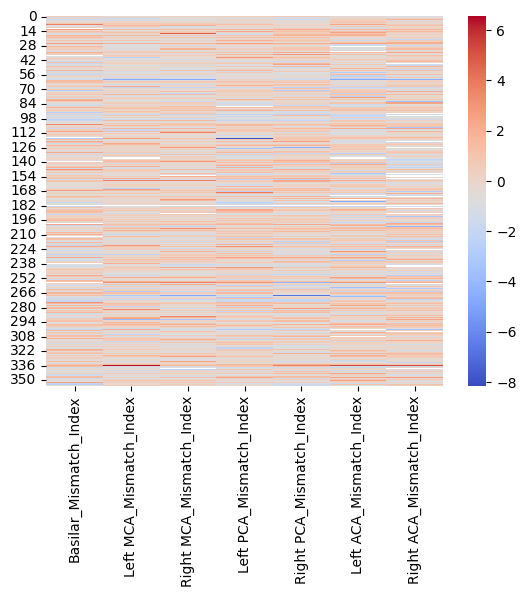

In [83]:
paired_map = {
    'Basilar': 'Right_Basilar-8',
    'Basilar': 'Left_Basilar-8',
    'Left MCA': 'Left_MCA-8',
    'Right MCA': 'Right_MCA-8',
    'Left PCA': 'Left_PCA-8',
    'Right PCA': 'Right_PCA-8',
    'Left ACA': 'Left_ACA-8',
    'Right ACA': 'Right_ACA-8',
}

mismatch_df = compute_vascular_mismatch(df_merged, paired_map)
sns.heatmap(mismatch_df, annot=False, cmap='coolwarm')